# Tutorial: apply an optical distortion model

This notebook compares the identity optical model with a fifth-order `SIPDistortion`. In the current warpfield interface, every distortion class receives coordinates with shape `(N_coordinate, 2)` and returns coordinate **displacements** with the same shape. When `imaging_radius` is defined, `Optics` normalizes the input focal-plane coordinates by that radius before evaluating the distortion, then adds the returned displacements to the ideal coordinates.

## 1. Imports and plotting configuration

All focal-plane panels use common square limits that contain the complete circular JASMINE field of view. Detector boundaries use the same node-0 marker and first-edge emphasis as Tutorials 05–07.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['legend.frameon'] = False
matplotlib.rcParams['figure.dpi'] = 72

In [2]:
import astropy.units as u

from warpfield import Pointing, SourceCatalog
from warpfield.distortion import IdentityDistortion, SIPDistortion
from warpfield.footprint import focalplane_footprints
from warpfield.model import get_jasmine

## 2. Define a regular sky grid

The source catalog is a regular grid around the origin of ICRS. A single `Pointing` places the optical axis at the grid center with position angle 0°.

In [3]:
axis = np.linspace(-0.24, 0.24, 25)
ra, dec = np.meshgrid(axis, axis)
source = SourceCatalog(ra.ravel(), dec.ravel())
pointing = Pointing.from_coord(
    'icrs', 0.0 * u.deg, 0.0 * u.deg, 0.0 * u.deg,
)

`project_sources()` evaluates the complete optical model. The plotting helper draws the nominal detector geometry for reference; as documented by `focalplane_footprints()`, those boundaries intentionally exclude distortion because drawing distorted boundaries would require the inverse detector mapping.

In [4]:
def project_sources(telescope, pointing, source):
    size = len(source)
    return np.asarray(telescope.focal_plane(
        np.full(size, pointing.ra[0]),
        np.full(size, pointing.dec[0]),
        np.full(size, pointing.position_angle[0]),
        source.ra,
        source.dec,
        np.ones((size, 1)),
    ))


def plot_focal_plane(ax, telescope, pointing, source, title):
    source_xy = project_sources(telescope, pointing, source)
    ax.scatter(source_xy[:, 0], source_xy[:, 1], s=5)
    for detector_id, boundary in enumerate(
            focalplane_footprints(telescope)):
        N = boundary.shape[0]
        ax.scatter(
            boundary[0, 0], boundary[0, 1],
            color=f'C{detector_id}', marker='o', s=25,
        )
        ax.plot(
            boundary[:N // 4 + 1, 0], boundary[:N // 4 + 1, 1],
            color=f'C{detector_id}', lw=3,
        )
        ax.plot(
            boundary[:, 0], boundary[:, 1],
            color=f'C{detector_id}', lw=1,
        )
    radius = telescope.optics.imaging_radius
    ax.add_patch(plt.Circle(
        (0.0, 0.0), radius, fill=False,
        color='gray', ls='--', lw=1,
    ))
    limit = 1.05 * radius
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect(1.0, adjustable='box')
    ax.grid(True, color='gray', alpha=0.5)
    ax.set_title(title, loc='left')
    ax.set_xlabel('Focal plane X (mm)')
    ax.set_ylabel('Focal plane Y (mm)')

## 3. Identity distortion

`get_jasmine()` returns a plain `Telescope` by default. Unless another model is supplied, its optics contain `IdentityDistortion`, which returns zero displacement everywhere.

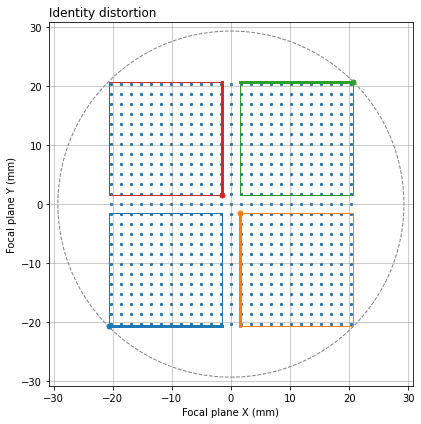

In [5]:
identity = get_jasmine()

assert isinstance(identity.optics.distortion, IdentityDistortion)

fig, ax = plt.subplots(figsize=(6, 6))
plot_focal_plane(
    ax, identity, pointing, source,
    title='Identity distortion',
)
fig.tight_layout()
plt.show()

## 4. Construct a SIP distortion

`SIPDistortion` stores 18 coefficients per coordinate: 3 second-order, 4 third-order, 5 fourth-order, and 6 fifth-order terms. Constant and affine terms are omitted. Here the nonzero third-order coefficients form a radial displacement proportional to

$$
(\Delta x, \Delta y) \propto \left(x(x^2+y^2),\;y(x^2+y^2)\right).
$$

The numerical strength below is intentionally exaggerated so that the effect is visible in a tutorial figure.

In [6]:
coeff_x = np.zeros(18)
coeff_y = np.zeros(18)
strength = 2.0e12

# Third-order ordering: x^3, x^2 y, x y^2, y^3
coeff_x[[3, 5]] = strength
coeff_y[[4, 6]] = strength

sip = SIPDistortion(coeff_x=coeff_x, coeff_y=coeff_y)
distorted = get_jasmine(distortion=sip)

The displacement field can be evaluated independently of the telescope. To reproduce the `Optics` convention, focal-plane coordinates are divided by `imaging_radius` before being passed to the distortion. This is useful when checking the sign, symmetry, and scale of a candidate model.

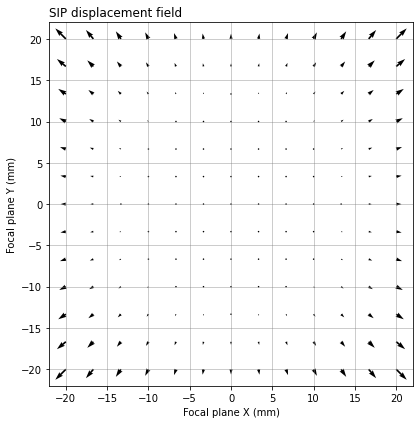

In [7]:
vector_axis = np.linspace(-20.0, 20.0, 13)
grid_x, grid_y = np.meshgrid(vector_axis, vector_axis)
grid_xy = np.column_stack([grid_x.ravel(), grid_y.ravel()])
normalized_xy = grid_xy / distorted.optics.imaging_radius
displacement = np.asarray(sip(normalized_xy))

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(
    grid_xy[:, 0], grid_xy[:, 1],
    displacement[:, 0], displacement[:, 1],
    angles='xy', scale_units='xy', scale=1.0,
)
ax.set_xlim(-22.0, 22.0)
ax.set_ylim(-22.0, 22.0)
ax.set_aspect(1.0, adjustable='box')
ax.grid(True, color='gray', alpha=0.5)
ax.set_title('SIP displacement field', loc='left')
ax.set_xlabel('Focal plane X (mm)')
ax.set_ylabel('Focal plane Y (mm)')
fig.tight_layout()
plt.show()

## 5. Compare the projected coordinates

Both panels use the same source catalog, pointing, detector geometry, and display limits. The only difference is `Optics.distortion`, making the displacement of the regular grid directly visible.

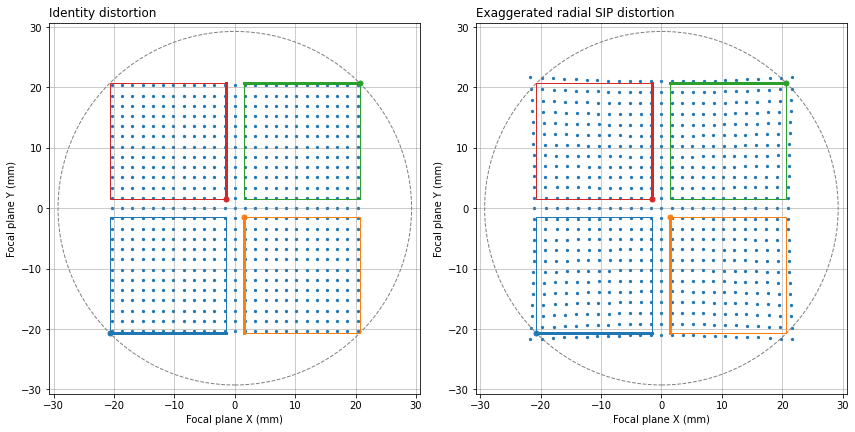

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_focal_plane(
    axes[0], identity, pointing, source,
    title='Identity distortion',
)
plot_focal_plane(
    axes[1], distorted, pointing, source,
    title='Exaggerated radial SIP distortion',
)
fig.tight_layout()
plt.show()

## Summary

- Distortion models accept and return arrays with shape `(N_coordinate, 2)`.
- Their return value is a displacement; `Optics` adds it to the ideal coordinate.
- `IdentityDistortion` returns zero displacement.
- `SIPDistortion` is a differentiable Zodiax PyTree whose coefficient arrays can be optimized.
- Passing `distortion=` to `get_jasmine()` constructs the same nominal instrument with a different optical distortion.